**Title**: Loss Function Design for Deep Image Prior Inpainting: An Empirical Analysis of MSE, SSIM, Perceptual, and Hybrid Approaches

**Abstract**: This project explores the role of loss function design in *Deep Image Prior* (DIP) inpainting, where a convolutional neural network is trained on a single image to reconstruct masked regions. I investigated a variety of loss functions including: MSE, L1, SSIM, perceptual loss (using VGG16), and hybrid combinations of them. I analyzed their effect across shallow and deep U-Net-style architectures. My experiments confirm that MSE tends to produce blurry results, while L1 and SSIM improve sharpness and structure respectively, albeit with issues in color accuracy. Perceptual loss introduces semantic realism but requires longer optimization and introduces color instability. Hybrid losses that combine multiple objectives (e.g. perceptual + SSIM + L1 + color + total variation) are shown to be highly sensitive to hyperparameter tuning and optimization (iteration) length. Notably, I find that shallow networks trained with a simple SSIM-L1 loss can outperform deeper models when constrained by compute time. These findings suggest that loss function design has a greater impact on subjective visual quality than model depth alone in DIP, and that hybrid approaches require careful calibration. 

# Introduction

Based on the *Deep Image Prior* (DIP) method proposed by [Ulyanov, Vedaldi, and Lempitsky](https://openaccess.thecvf.com/content_cvpr_2018/papers/Ulyanov_Deep_Image_Prior_CVPR_2018_paper.pdf), I implemented several network architectures and loss functions to explore image inpainting without external training data. DIP involves training an overparameterized, randomly initialized convolutional network on a single image, allowing the network structure itself to act as a natural image prior. In this project, I experiment with refinements to the original DIP approach, focusing on the effects of network size and depth, loss function design, and a hybrid approach inspired by GAN-based perceptual techniques that incorporate a feature-space (perceptual) loss instead of a simple pixel-wise error. As noted in the project description, an L2 loss function typically gives blurrier results. We will see that our L1- and SSIM- loss function increase sharpness. 

To ensure a fair comparison across methods, each experiment is allocated approximately the same processing time (10-15 minutes). Although they do differ significantly in the amount of resources (e.g. VRAM) used. As a result, some methods are trained for more or fewer iterations depending on their computational efficiency. For instance, smaller networks often converge faster and yield surprisingly strong results within the time budget, while more computationally intensive approaches, such as those using perceptual losses, tend to underperform given the same time constraint. It is also important to note that generally each method does 100 iterations. Additionally, inpainting is done in a central rectangle of the image.

### Code libraries
1. `cv2` is used for image loading, saving, and manipulation
2. `numpy` is used for mathematical operations
3. `torch` is used for create, training, and running neural networks
4. `matplotlib` is used for creating plots
5. `pytorch_msssim` is used to calculate the SSIM of an image, it is used for the SSIM-L1 loss function. Can be installed via `pip install pytorch-msssim`.
6. `torchvision.models` is used to obtain and extract the VGG16 model, it is used for the perceptual loss function

In [1]:
import cv2
import numpy as np
import numpy.typing as npt
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import os
from pytorch_msssim import ssim
from typing import Tuple
import torchvision.models as models

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

The following functions: `pad_to_scale` and `DIP_image` are helper functions used to train and evaluate models. The `model_scale` argument is used to ensure the image dimension matches the required for the model, i.e. it must be divisible by 4. By pads the image so that this requirement is met. I had this problem while testing on different images.

In [3]:
def pad_to_scale(img: npt.NDArray, scale: int):
    H, W = img.shape[:2]
    pad_h = (scale - H % scale) % scale
    pad_w = (scale - W % scale) % scale

    pad_top = pad_h // 2
    pad_bottom = pad_h - pad_top
    pad_left = pad_w // 2
    pad_right = pad_w - pad_left

    padded_img = np.pad(img, ((pad_top, pad_bottom), (pad_left, pad_right), (0, 0)), mode='reflect')
    return padded_img, (pad_top, pad_bottom, pad_left, pad_right)


def DIP_image(
    input_image_path: str,
    iterations: int, 
    model_scale: int,
    net: nn.Module,
    optimizer: torch.optim.Optimizer,
    loss_fn: nn.Module,
    print_loss_every: int = -1,
    show_intermediate_every: int = -1, # -1 is never 
    save_intermediate_folder: str = "",
    show_final: bool = True,
    save_final_file: str = "",
) -> npt.NDArray:
    if not os.path.exists(input_image_path):
        raise Exception(f"The file `{input_image_path}` doesn't exist.")
    
    img_bgr = cv2.imread(input_image_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img = img_rgb.astype(np.float32) / 255.0 # Normalize the image
    
    # Some models require the input image to be divisible by some number, so we scale
    img, pad = pad_to_scale(img, scale=model_scale)
    H, W, C = img.shape
    
    # Create the mask
    mask = np.ones((H, W), dtype=np.float32)
    rect_h, rect_w = H // 4, W // 4
    rect_y, rect_x = (H - rect_h) // 2, (W - rect_w) // 2
    mask[rect_y:rect_y+rect_h, rect_x:rect_x+rect_w] = 0.0
    
    masked_img = img.copy()
    masked_img[mask == 0] = 0.0
    
    # Convert to tensor
    img_tensor = torch.from_numpy(img.transpose(2, 0, 1)).unsqueeze(0).to(device) # [1, 3, H, W]
    mask_tensor = torch.from_numpy(mask).unsqueeze(0).unsqueeze(0).to(device) # [1, 1, H, W]
    input_noise = torch.randn((1, 32, H, W)).to(device) # This is the fixed noise that DIP will generate based on
    
    if save_intermediate_folder != "":
        if not os.path.exists(save_intermediate_folder):
            os.mkdir(save_intermediate_folder)
        pass
    
    for it in range(iterations):
        optimizer.zero_grad()
        output = net(input_noise)
        loss = loss_fn(output, img_tensor, mask_tensor)
        loss.backward()
        optimizer.step()
        
        if print_loss_every != -1 and (it % print_loss_every == 0 or it == iterations - 1):
            print(f"Iter {it}, loss = {loss.item():.6f}")
            pass

        if show_intermediate_every != -1 and it % show_intermediate_every == 0:           
            # Combine known pixels with inpainted result
            output_np = output.detach().cpu().numpy()[0].transpose(1, 2, 0)
            result_np = output_np * (1 - mask[..., None]) + img * mask[..., None]
            result_np = np.clip(result_np, 0, 1)

            fig, axs = plt.subplots(1, 3, figsize=(12, 4))
            fig.suptitle(f"Loss={loss.item()}")
            axs[0].imshow(img)
            axs[0].set_title("Original")
            axs[1].imshow(masked_img)
            axs[1].set_title("Masked")
            axs[2].imshow(result_np)
            axs[2].set_title(f"DIP Output @ iter {it}")
            for ax in axs:
                ax.axis("off")
            plt.tight_layout()
            plt.show()
            
            if save_intermediate_folder != "":
                cv2.imwrite(
                    os.path.join(save_intermediate_folder, f"i-{str(it).zfill(len(str(show_intermediate_every)))}.jpg"), 
                    cv2.cvtColor((result_np * 255).astype(np.uint8), cv2.COLOR_RGB2BGR))  
                pass
            
            pass
            
    # Now evaluate the final result
    output_final = net(input_noise).detach().cpu().numpy()[0].transpose(1, 2, 0)
    inpainted_final = output_final * (1 - mask[..., None]) + img * mask[..., None]
    inpainted_final = np.clip(inpainted_final, 0, 1)

    if show_final:
        plt.imshow(inpainted_final)

    if save_final_file != "":
        cv2.imwrite(save_final_file, cv2.cvtColor((inpainted_final * 255).astype(np.uint8), cv2.COLOR_RGB2BGR)) 
        pass
    
    return inpainted_final

### Test image:

![Test image](./input_images/image_1.jpg)

![The masked input image](./input_images/masked_image_1.png)

This image was used to test inpainting. The inpainting is done on a central rectangle in the image. This image was chosen because it would be a challenge for this approach. There is a mix of near (and therefore sharp) and far (and therefore blurry) focuses. In addition there is a "pattern" in the color, that near the bottom of the image the shade of green is darker, but at the top is is lighter. And finally there is the bright-red bird, seeing if the method "memorizes" it would be a sign of overfitting since the method would no longer be learning the density distribution of the masked image, but rather of the input image.

# Shallow Net with MSE loss

In [4]:
class MaskedMSELoss(nn.Module):
    def forward(self, output, target, mask):
        return torch.mean(((output - target) * mask) ** 2)

In [5]:
class ShallowDownBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=2, padding=1),
            nn.InstanceNorm2d(out_ch, affine=True),
            nn.LeakyReLU(0.1, inplace=True),
        )

    def forward(self, x):
        return self.block(x)

class ShallowUpBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.InstanceNorm2d(out_ch, affine=True),
            nn.LeakyReLU(0.1, inplace=True),
        )

    def forward(self, x):
        return self.block(x)
    
class ShallowDIPNetwork(nn.Module):
    def __init__(self, input_channels=32, base_channels=64):
        super().__init__()

        # Encoder
        self.enc1 = nn.Sequential(
            nn.Conv2d(input_channels, base_channels, kernel_size=3, padding=1),
            nn.InstanceNorm2d(base_channels, affine=True),
            nn.LeakyReLU(0.1, inplace=True),
        )
        self.down1 = ShallowDownBlock(base_channels, base_channels * 2)
        self.down2 = ShallowDownBlock(base_channels * 2, base_channels * 4)

        # Decoder
        self.up1 = ShallowUpBlock(base_channels * 4, base_channels * 2)
        self.up2 = ShallowUpBlock(base_channels * 2 + base_channels * 2, base_channels)
        self.out_layer = nn.Sequential(
            nn.Conv2d(base_channels + base_channels, 3, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        # Encoder
        x1 = self.enc1(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)

        # Decoder with skip connections
        x = self.up1(x3)
        x = torch.cat([x, x2], dim=1)
        x = self.up2(x)
        x = torch.cat([x, x1], dim=1)
        return self.out_layer(x)

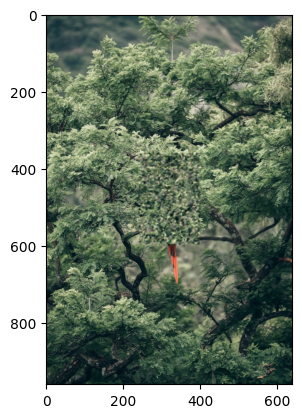

In [51]:
shallow_net = ShallowDIPNetwork().to(device)
shallow_optimizer = torch.optim.Adam(shallow_net.parameters(), lr=0.01)
shallow_loss_fn = MaskedMSELoss().to(device)
DIP_image(
    input_image_path="./input_images/image_1.jpg", 
    iterations=500, 
    model_scale=4, 
    net=shallow_net, 
    optimizer=shallow_optimizer, 
    loss_fn=shallow_loss_fn, 
    show_final=True, 
    save_final_file="./output_images/shallow-mse/inpainted_1.jpg",
)
# Delete to free up more VRAM
del shallow_net
del shallow_optimizer
del shallow_loss_fn

To establish a lightweight baseline, I implemented a shallow encoder-decoder network trained with a masked mean squared error (MSE) loss. The architecture is a simplified U-Net variant that consists of two downsampling and two upsampling blocks with skip connections at each scale. Instance normalization is used to stabilize training and Leaky ReLU serves as the activation function. 

The network takes as input a fixed noise tensor with 32 channels and gradually upsamples to produce a 3-channel RBG image via a final $1 \times 1$ convolution followed by a sigmoid activation to constrain output pixel values to $[0, 1]$.

The shallow architecture is intentionally underparameterized compared to classical DIP models and thus converges quickly. However, it lacks the capacity to learn global semantic structures or fine texture continuity. As seen in the output image (see above), this model produces a noisy and spatially incoherent inpainting, particularly in regions with complex textures such as tree branches. The blurriness is a direct consequence of the pixel-wise L2 loss, which tends to average out plausible reconstructions in areas of uncertainty.

Moreover, the model exhibits poor boundary awareness. The transition between the inpainted region and the original image is abrupt.

Despite these limitations, the shallow network serves as a useful computational baseline. It can deliver a rough inpainting within a short time budget (roughly 10 minutes) and offers a comparison point against deeper architectures or perceptual loss methods.

# Deep Net with MSE loss

In [6]:
class DeepDownBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=2, padding=1),
            nn.InstanceNorm2d(out_ch, affine=True),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.InstanceNorm2d(out_ch, affine=True),
            nn.LeakyReLU(0.1, inplace=True),
        )

    def forward(self, x):
        return self.block(x)

class DeepUpBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.InstanceNorm2d(out_ch, affine=True),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.InstanceNorm2d(out_ch, affine=True),
            nn.LeakyReLU(0.1, inplace=True),
        )

    def forward(self, x):
        return self.block(x)
    
class DeepDIPNetwork(nn.Module):
    def __init__(self, input_channels=32, base_channels=64):
        super().__init__()

        self.enc1 = nn.Sequential(
            nn.Conv2d(input_channels, base_channels, 3, padding=1),
            nn.InstanceNorm2d(base_channels, affine=True),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Conv2d(base_channels, base_channels, 3, padding=1),
            nn.InstanceNorm2d(base_channels, affine=True),
            nn.LeakyReLU(0.1, inplace=True),
        )
        self.down1 = DeepDownBlock(base_channels, base_channels * 2)
        self.down2 = DeepDownBlock(base_channels * 2, base_channels * 4)
        self.down3 = DeepDownBlock(base_channels * 4, base_channels * 8)

        # With skip connections
        self.up1 = DeepUpBlock(base_channels * 8, base_channels * 4)
        self.up2 = DeepUpBlock((base_channels * 4) + (base_channels * 4), base_channels * 2)
        self.up3 = DeepUpBlock((base_channels * 2) + (base_channels * 2), base_channels)

        # Final conv + skip from enc1
        self.out_layer = nn.Sequential(
            nn.Conv2d(base_channels + base_channels, 3, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        # Encoder
        x1 = self.enc1(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)

        # Decoder with skip connections
        y = self.up1(x4)
        y = torch.cat([y, x3], dim=1)
        y = self.up2(y)
        y = torch.cat([y, x2], dim=1)
        y = self.up3(y)
        y = torch.cat([y, x1], dim=1)

        return self.out_layer(y)

Iter 0, loss = 0.072168
Iter 10, loss = 0.027158
Iter 20, loss = 0.014446
Iter 30, loss = 0.011672
Iter 40, loss = 0.010198
Iter 50, loss = 0.009077
Iter 60, loss = 0.008221
Iter 70, loss = 0.007500
Iter 80, loss = 0.006944
Iter 90, loss = 0.006428
Iter 99, loss = 0.005921


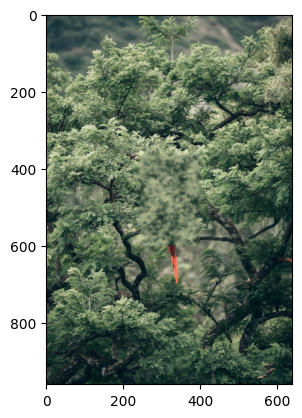

In [53]:
deep_net = DeepDIPNetwork().to(device)
deep_optimizer = torch.optim.Adam(deep_net.parameters(), lr=0.01)
deep_loss_fn = MaskedMSELoss().to(device)
DIP_image(
    input_image_path="./input_images/image_1.jpg", 
    iterations=100, 
    model_scale=4, 
    net=deep_net, 
    optimizer=deep_optimizer, 
    loss_fn=deep_loss_fn, 
    show_final=True, 
    save_final_file="./output_images/deep-mse/inpainted_1.jpg",
    print_loss_every=10
)
# The deeper model can take 8GB, meaning all my VRAM + 2 GB of shared RAM
del deep_net
del deep_optimizer
del deep_loss_fn

This model architecture is very similar to the previous (in fact all models will have roughly the same U-Net like architecture or be deeper) except that it has an extra encoder and decoder layers, paired with additional convolutional blocks. Compared to the shallow variant, this deeper model has a significantly larger receptive field and can encode multi-scale contextual information, which is essential for coherent image inpainting.

In contrast to the shallower architecture, the deep model exhibits clear improvements in structural coherence and noise suppression. As shown in the output image (see above), the inpainted region blends more smoothly with its surroundings and lacks the high-frequency artifacts present in the shallow output. Notably, the model begins to infer plausible global structure such as leaf clusters and soft shading. 

However, the result remains visibly blurry, particularly in high-frequency texture areas like foliage. This limitation stems from the L2 loss, which tends to produce spatial averages in uncertain regions. This observation suggests that increasing model capacity alone is not sufficient for high-quality inpainting, designing the right loss function is also important. MSE provides pixel-wise supervision but fails to capture perceptual fidelity or texture sharpness, motivating exploration of SSIM-L1 loss or perceptual losses in subsequent experiments.

# Deeper Net, using MSE

In [8]:
class DeeperDownBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=2, padding=1),
            nn.InstanceNorm2d(out_ch, affine=True),
            nn.LeakyReLU(0.1, inplace=True),

            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.InstanceNorm2d(out_ch, affine=True),
            nn.LeakyReLU(0.1, inplace=True),
        )

    def forward(self, x):
        return self.block(x)

class DeeperUpBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.InstanceNorm2d(out_ch, affine=True),
            nn.LeakyReLU(0.1, inplace=True),

            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.InstanceNorm2d(out_ch, affine=True),
            nn.LeakyReLU(0.1, inplace=True),
        )

    def forward(self, x):
        return self.block(x)

class DeeperDIPNetwork(nn.Module):
    def __init__(self, input_channels=32, base_channels=64):
        super().__init__()

        self.enc1 = nn.Sequential(
            nn.Conv2d(input_channels, base_channels, 3, padding=1),
            nn.InstanceNorm2d(base_channels, affine=True),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Conv2d(base_channels, base_channels, 3, padding=1),
            nn.InstanceNorm2d(base_channels, affine=True),
            nn.LeakyReLU(0.1, inplace=True),
        )
        self.down1 = DeeperDownBlock(base_channels, base_channels * 2)
        self.down2 = DeeperDownBlock(base_channels * 2, base_channels * 4)
        self.down3 = DeeperDownBlock(base_channels * 4, base_channels * 8)
        self.down4 = DeeperDownBlock(base_channels * 8, base_channels * 16)

        # With skip connections
        self.up0 = DeeperUpBlock(base_channels * 16, base_channels * 8)
        self.up1 = DeeperUpBlock(base_channels * 8 + base_channels * 8, base_channels * 4)
        self.up2 = DeeperUpBlock(base_channels * 4 + base_channels * 4, base_channels * 2)
        self.up3 = DeeperUpBlock(base_channels * 2 + base_channels * 2, base_channels)

        self.out_layer = nn.Sequential(
            nn.Conv2d(base_channels + base_channels, 3, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        # Encoder
        x1 = self.enc1(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        # Decoer with skip connections
        y = self.up0(x5)
        y = torch.cat([y, x4], dim=1)
        y = self.up1(y)
        y = torch.cat([y, x3], dim=1)
        y = self.up2(y)
        y = torch.cat([y, x2], dim=1)
        y = self.up3(y)
        y = torch.cat([y, x1], dim=1)

        return self.out_layer(y)

Iter 0, loss = 0.057592
Iter 10, loss = 0.026740
Iter 20, loss = 0.015534
Iter 30, loss = 0.012226
Iter 40, loss = 0.010791
Iter 50, loss = 0.009732
Iter 60, loss = 0.008828
Iter 70, loss = 0.008006
Iter 80, loss = 0.007259
Iter 90, loss = 0.006625
Iter 99, loss = 0.006178


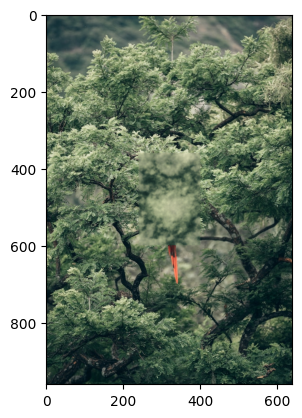

In [55]:
deeper_net = DeeperDIPNetwork().to(device)
deeper_optimizer = torch.optim.Adam(deeper_net.parameters(), lr=0.01)
deeper_loss_fn = MaskedMSELoss().to(device)
DIP_image(
    input_image_path="./input_images/image_1.jpg", 
    iterations=100, 
    model_scale=16, 
    net=deeper_net, 
    optimizer=deeper_optimizer, 
    loss_fn=deeper_loss_fn, 
    show_final=True, 
    save_final_file="./output_images/deeper-mse/inpainted_1.jpg",
    print_loss_every=10
)
del deeper_net
del deeper_optimizer
del deeper_loss_fn

Above is the output of the `DeeperDIPNetwork` trained with masked MSE loss. Despite having more layers, the model produces an overly smoothed inpainting that lacks internal structure. This suggests that excessive depth without an adequate loss function may harm detail reconstruction.

The `DeeperDIPNetwork` model has 4 encoder/decoder layers, once again following an U-Net design. The expectation was that increasing model depth would enable richer features and more nuanced spatial understanding. However, qualitative results suggest diminishing returns beyond a certain depth. One reason for this might be the limited time given, although I do not expect so since the final loss produced ($0.006178$) is roughly on par with that of `DeepDIPNetwork` ($0.005921$). However with only 100 iterations, the deeper layers may have went under-utilized, since deeper layers are slower to converge.

In general I would say that the `DeepDIPNetwork`, not `DeeperDIPNetwork` is the sweet spot for depth, given the constraints under which I am evaluating these models.

# SSIM and L1 Loss

To address the limitations of pixel-wise losses like MSE, which often result in blurred reconstructions, I explored a composite loss function combining Structural Similarity Index (SSIM) and L1 loss. SSIM is a perceptual metric introduced by [Wang, Bovik, Sheikh, and Simoncelli](https://www.cns.nyu.edu/pub/lcv/wang03-preprint.pdf) in their 2004 paper. It assesses image quality by comparing local patterns of luminance, contrast, and structure. Since this is a more "human-tuned" solution, I think that it might be helpful in providing more realistic inpainting compared to a more mathematical (such as MSE or L1) loss function when it comes to inpainting. However, SSIM alone does not enforce absolute pixel fidelity, which is why I incorporated L1 loss, to produce sharper images than MSE.

In [9]:
class SSIM_L1_Loss(nn.Module):
    def __init__(self, alpha: float):
        super().__init__()
        self.alpha = alpha # weight between SSIM and L1

    def forward(self, output, target, mask):
        # Compute L1 and SSIM only on known pixels
        mask3 = mask.repeat(1, 3, 1, 1)
        output_masked = output * mask3
        target_masked = target * mask3

        # SSIM expects values in [0, 1]
        ssim_loss = 1 - ssim(output_masked, target_masked, data_range=1.0, size_average=True)
        l1_loss = F.l1_loss(output_masked, target_masked)

        return self.alpha * ssim_loss + (1 - self.alpha) * l1_loss

## Deep Net using SSIM and L1 loss, with emphasis on SSIM

Iter 0, loss = 0.767195
Iter 10, loss = 0.561640
Iter 20, loss = 0.401453
Iter 30, loss = 0.281974
Iter 40, loss = 0.218434
Iter 50, loss = 0.185755
Iter 60, loss = 0.153624
Iter 70, loss = 0.139688
Iter 80, loss = 0.120481
Iter 90, loss = 0.109113
Iter 99, loss = 0.101776


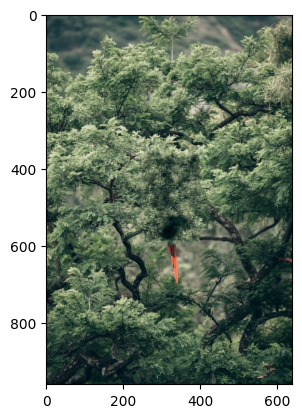

In [57]:
ssm_net = DeepDIPNetwork().to(device)
ssm_optimizer = torch.optim.Adam(ssm_net.parameters(), lr=0.01)
ssm_loss_fn = SSIM_L1_Loss(alpha=0.85).to(device)
DIP_image(
    input_image_path="./input_images/image_1.jpg", 
    iterations=100, 
    model_scale=8, 
    net=ssm_net, 
    optimizer=ssm_optimizer, 
    loss_fn=ssm_loss_fn, 
    show_final=True, 
    save_final_file="./output_images/ssm-l1-strong/inpainted_1.jpg",
    print_loss_every=10
)
del ssm_net
del ssm_optimizer
del ssm_loss_fn

This configuration favors structural similarity over pixel-wise precision. The resulting inpainted region is noticeably sharper than those generated using pure MSE or L1 losses. Leaf textures and edge contrast are better preserved, and the image exhibits greater coherence with its surroundings. 

However, a few downsides are apparent. The overall brightness of the inpainted region is darker than expected (and subjectively not too pretty), deviating from the color balance of the original image. And there is also a prominent dark patch near the bottom-center of the masked area, suggesting instability in luminance reconstruction. That is to say, the initial random noise in that area might have been darker (due to randomness) and that cascaded.

These artifacts may arise because SSIM does not penalize global brightness shifts as long as structural correlations are preserved. For instance, [Wang, Bovik, Sheikh, and Simoncelli](https://ece.uwaterloo.ca/~z70wang/publications/SSIM_Chap.pdf), note that " the change of luminance and/or contrast has little impact on the structures of images". This will eventually lead to the inclusion of a color loss term in future models.

## Deep Net using SSIM and L1 loss, with emphasis on L1

Iter 0, loss = 0.289276
Iter 10, loss = 0.188999
Iter 20, loss = 0.154206
Iter 30, loss = 0.136217
Iter 40, loss = 0.120496
Iter 50, loss = 0.105246
Iter 60, loss = 0.092331
Iter 70, loss = 0.081863
Iter 80, loss = 0.074515
Iter 90, loss = 0.067356
Iter 99, loss = 0.062227


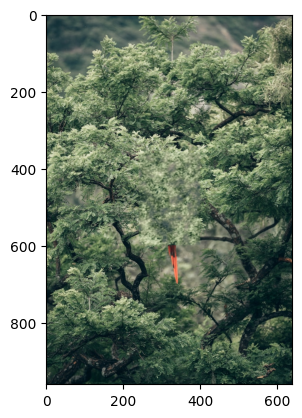

In [58]:
ssm_net = DeepDIPNetwork().to(device)
ssm_optimizer = torch.optim.Adam(ssm_net.parameters(), lr=0.01)
ssm_loss_fn = SSIM_L1_Loss(alpha=1-0.85).to(device)
DIP_image(
    input_image_path="./input_images/image_1.jpg", 
    iterations=100, 
    model_scale=8, 
    net=ssm_net, 
    optimizer=ssm_optimizer, 
    loss_fn=ssm_loss_fn, 
    show_final=True, 
    save_final_file="./output_images/ssm-l1-weak/inpainted_1.jpg",
    print_loss_every=10
)
del ssm_net
del ssm_optimizer
del ssm_loss_fn

Shifting the emphasis toward L1 loss yields a brighter and somewhat smoother reconstruction comapred to SSIM, but compared to L2 it is slightly better. The inpainted region better matches the tonal range of the surrounding image, avoiding the dark cast introduced by the SSIM-heavy model. However, this comes at the cost of sharpness and structural detail. Leaf textures appear more diffused, and some grayish patches reduce realism. Additionally is it generally uniform across the inpainted region, once again not conforming well to boundary areas.

So we see a trade off between SSIM and L1. L1 enforces pixel-wise alignment but ignores higher-order spatial patterns. But SSIM enhances perceptual coherence but can allow local or global brightness artifacts.

These results demonstrate that combining SSIM with L1 can improve perceptual quality over using either alone, but the weighting must be carefully tuned. A moderate mix (e.g. 50/50) might balance structural preservation and tonal accuracy. The SSIM-heavy model produced sharper but darker outputs, while the L1-heavy model offered brighter yet less coherent results.

# Deep Net using perceptual Loss with VGG16

In [11]:
class VGGFeatureExtractor(nn.Module):
    def __init__(self, layers: Tuple[int,...]):
        super().__init__()
        vgg = models.vgg16(pretrained=True).features
        self.selected_layers = layers
        self.vgg = vgg
        for param in self.vgg.parameters():
            param.requires_grad = False

    def forward(self, x):
        features = []
        for i, layer in enumerate(self.vgg):
            x = layer(x)
            if i in self.selected_layers:
                features.append(x)
        return features

class PerceptualLoss(nn.Module):
    def __init__(self, layers: Tuple[int,...]):
        super().__init__()
        self.vgg_extractor = VGGFeatureExtractor(layers=layers).to(device)
    
    def forward(self, output, target, mask):
        # Prepare masked tensors
        mask3 = mask.repeat(1, 3, 1, 1)
        out_m = output * mask3
        tgt_m = target * mask3
        
        # Perceptual loss
        feats_out = self.vgg_extractor(out_m)
        feats_tgt = self.vgg_extractor(tgt_m)
        perceptual_loss = 0
        for fo, ft in zip(feats_out, feats_tgt):
            perceptual_loss += F.l1_loss(fo, ft)
        
        return perceptual_loss

c:\Users\Emu\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Emu\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Iter 0, loss = 1.529926
Iter 10, loss = 1.124426
Iter 20, loss = 1.107633
Iter 30, loss = 1.101504
Iter 40, loss = 1.097012
Iter 50, loss = 1.093323
Iter 60, loss = 1.088894
Iter 70, loss = 1.083195
Iter 80, loss = 1.077074
Iter 90, loss = 1.068078
Iter 99, loss = 1.056523


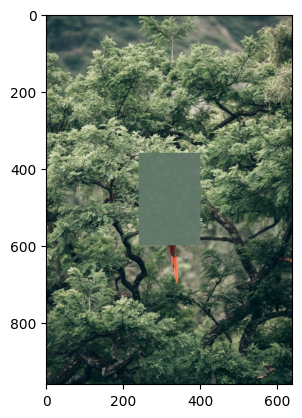

In [60]:
perceptual_net = DeepDIPNetwork().to(device)
perceptual_optimizer = torch.optim.Adam(perceptual_net.parameters(), lr=0.01)
perceptual_loss_fn = PerceptualLoss(layers=(3, 8, 15, 22)).to(device)
DIP_image(
    input_image_path="./input_images/image_1.jpg", 
    iterations=100, 
    model_scale=8, 
    net=perceptual_net, 
    optimizer=perceptual_optimizer, 
    loss_fn=perceptual_loss_fn, 
    show_final=True, 
    save_final_file="./output_images/perceptual/inpainted_1.jpg",
    print_loss_every=10
)
del perceptual_net
del perceptual_optimizer
del perceptual_loss_fn

To encourage semantically meaningful inpainting, I employed a perceptual loss derived from a pre-trained VGG16 network. There is similar to work by [Johnson, Alahi, and Fei-Fei](https://arxiv.org/pdf/1603.08155) which uses perceptual loss (using VGG16) for style transfer and super-resolution, however they trained on a dataset, and not a single image like in DIP. This is applying the same concept, perceptual loss, to DIP. Unlike pixel-based losses (e.g. MSE, L1) which only evaluate per-pixel fidelity, perceptual loss measures the similarity of feature representations between the generated and target images, focusing on texture, style, and object structure. I use the same [layers](https://arxiv.org/pdf/1603.08155#page=9), that is to say: `relu1_2` (3), `relu2_2` (8), `relu3_3` (15), and `relu4_3` (22). I also run the models for significantly less time (around 10 minutes or so) versus the paper which used 4 hours, which helps explain the worse results. (As a side note, eventually Ulyanov, Vedaldi, and Lempitsky would build on this work by Johnson, Alahi, and Fei-Fei ([link](https://github.com/mdehling/johnson-fast-style-transfer#:~:text=Ulyanov%2C%20Vedaldi%2C%20and%20Lempitsky)) which I found interesting)

As shown in the image (see above), the output is a flat, greenish region with subtle structure beginning to merge. At 100 iterations, the perceptual loss remained high (1.0565), indicating the model is still early in convergence. This is consistent with expectations.

Perceptual loss is compuationally expensive, each forward pass through VGG16 adds significant overhead, especially when extracting features at multiple layers. Optimization is also harder since the network must learn to match high-level features without direct pixel-wise feedback. Structure is also hard to form. Unlike L1 or SSIM, perceptual loss does not directly penalize differences in brightness or edges. Instead, it guides the network toward feature-level alignment, which emerges more slowly.

# Deep Net with perceptual loss (20 minutes)

Iter 0, loss = 1.556570
Iter 50, loss = 1.074720
Iter 100, loss = 0.909805
Iter 150, loss = 0.661661
Iter 200, loss = 0.508330
Iter 250, loss = 0.435400
Iter 300, loss = 0.389902
Iter 350, loss = 0.362917
Iter 399, loss = 0.322339


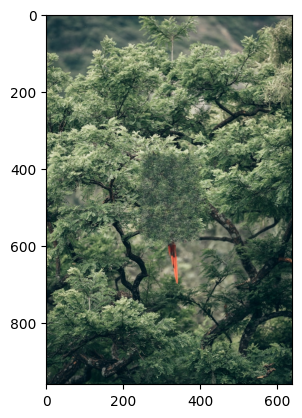

In [13]:
perceptual_net = DeepDIPNetwork().to(device)
perceptual_optimizer = torch.optim.Adam(perceptual_net.parameters(), lr=0.01)
perceptual_loss_fn = PerceptualLoss(layers=(3, 8, 15, 22)).to(device)
DIP_image(
    input_image_path="./input_images/image_1.jpg", 
    iterations=400, 
    model_scale=8, 
    net=perceptual_net, 
    optimizer=perceptual_optimizer, 
    loss_fn=perceptual_loss_fn, 
    show_final=True, 
    save_final_file="./output_images/perceptual/inpainted_1_deep.jpg",
    print_loss_every=50,
)
del perceptual_net
del perceptual_optimizer
del perceptual_loss_fn

To evaluate the long-term potential of perceptual loss under the Deep Image Prior framework, I extended training to 400 iterations using the same VGG16 feature layers as usual. The output image exhibits significantly improved structure, boundary blending, and texture realism compared to earlier iterations. Notable the leaves in the inpainted region is better integrated with sourrounding textures. However the region remains visibly darker, this might be due to VGG strong and certain layers being more focused on structure versus luminance.

# Deeper Net with perceptual loss (stopped after 130 minutes)

c:\Users\Emu\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Emu\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Iter 0, loss = 1.525565


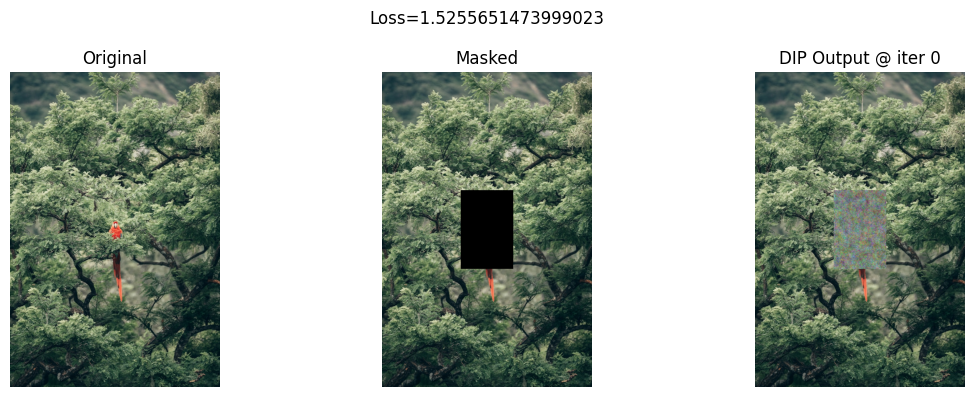

Iter 50, loss = 1.085091


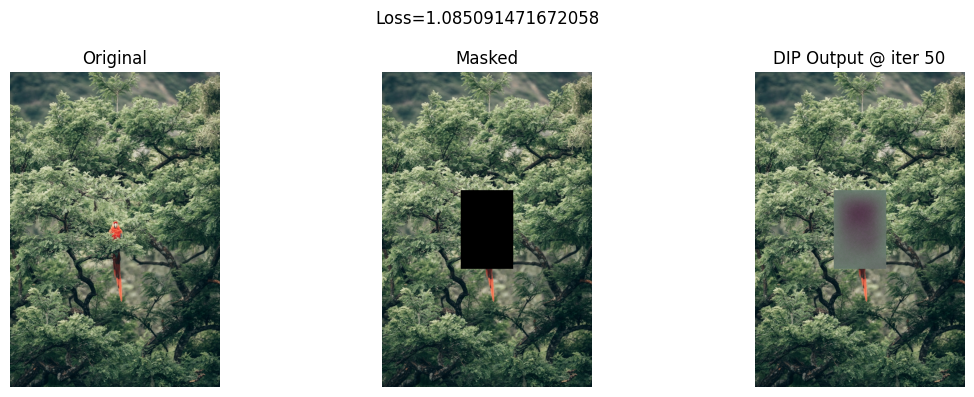

Iter 100, loss = 1.008620


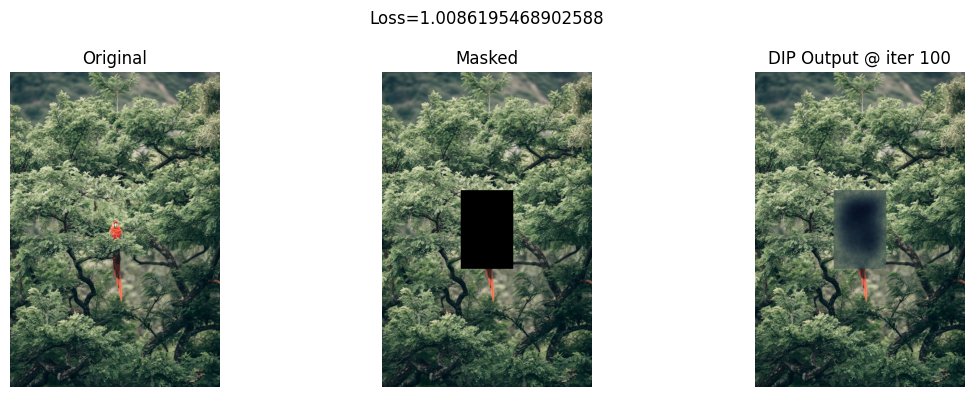

Iter 150, loss = 0.776049


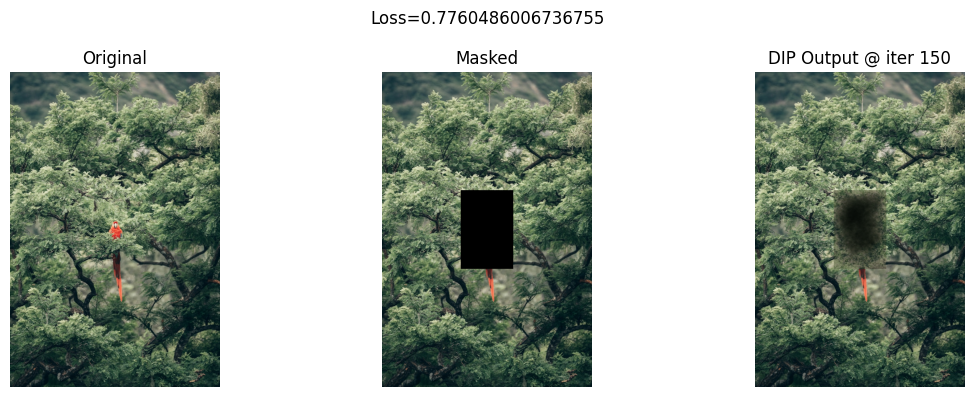

Iter 200, loss = 0.586758


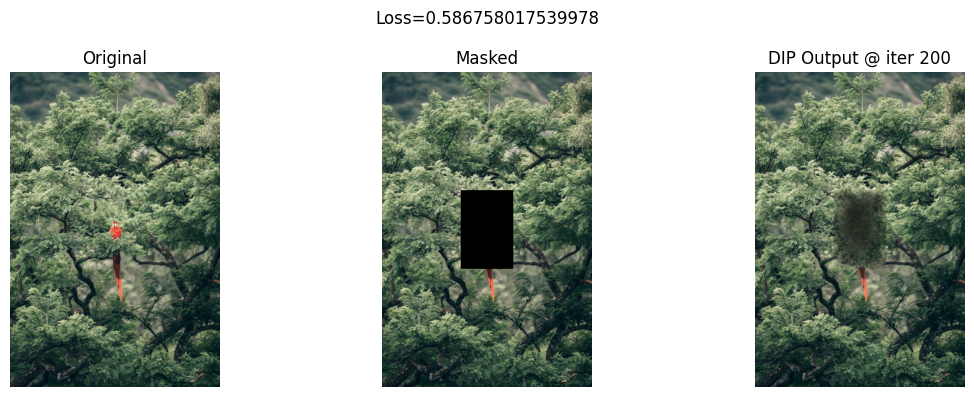

Iter 250, loss = 0.475401


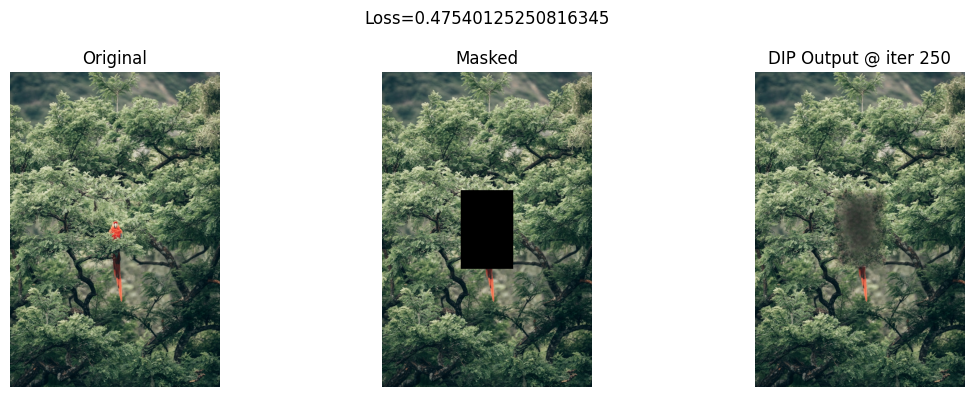

In [ ]:
perceptual_net = DeeperDIPNetwork().to(device)
perceptual_optimizer = torch.optim.Adam(perceptual_net.parameters(), lr=0.01)
perceptual_loss_fn = PerceptualLoss(layers=(3, 8, 15, 22)).to(device)
DIP_image(
    input_image_path="./input_images/image_1.jpg", 
    iterations=500, 
    model_scale=8, 
    net=perceptual_net, 
    optimizer=perceptual_optimizer, 
    loss_fn=perceptual_loss_fn, 
    show_final=True, 
    save_final_file="./output_images/perceptual/inpainted_1_deeper.jpg",
    print_loss_every=50,
    show_intermediate_every=50
)
del perceptual_net
del perceptual_optimizer
del perceptual_loss_fn

To investigate how model depth affects perceptual inpainting, I trained a `DeeperDIPNetwork` with my perceptual loss function. This model has four downsampling/upsampling stages and a significantly larger parameter count than the standard `DeepDIPNetwork`. I stopped the run early at iteration 250 (~130 minutes) due to slow convergence.

The images show that perceptual loss with a deep model converges significantly slower, with the network requiring hundreds of iterations to progress from a smooth blob to semantically plausible structure.

Perceptual loss suppresses noise early, by iteration 50 all the noise is gone and there is one blob with a flat background. The darker tone bias persists and is more severe than in shallower model, this may once again be due to a lack of a color loss function, and that deeper model takes longer to align with VGG (via the loss function).

However by iteration 250, we see the onset of meaningful structures, leave boundaries and texture frequencies that match the rest of the image, especially near the masked boundary.

This method bridges the gap between DIP and GAN based inpainting, leveraging the feature representations of a classification model (VGG) as a constraint for image generation. This hybrid approach in the end seems like a slower and less generalization approach to inpainting. I will continue to less it, but only has a part of a loss function in order to have some semantic inpainting and not just pixel-wise.

# Deep Net using perceptual + SSIM + L1 loss function

In [61]:
class Perceptual_SSM_L1_Loss(nn.Module):
    def __init__(self, perceptual_strength: float, perceptual_layers: Tuple[int, ...], ssm_strength: float, L1_strength: float):
        super().__init__()
        self.perceptual_strength = perceptual_strength
        self.ssm_strength = ssm_strength
        self.L1_strength = L1_strength
        self.vgg_extractor = VGGFeatureExtractor(layers=perceptual_layers).to(device)

    def forward(self, output, target, mask):
        mask3 = mask.repeat(1, 3, 1, 1)
        out_m = output * mask3
        tgt_m = target * mask3

        ssim_loss = 1 - ssim(out_m, tgt_m, data_range=1.0, size_average=True)
        l1_loss = F.l1_loss(out_m, tgt_m)
        perceptual_loss = sum(F.l1_loss(a, b) for a, b in zip(
            self.vgg_extractor(out_m), self.vgg_extractor(tgt_m)
        ))

        return (self.ssm_strength * ssim_loss +
                self.L1_strength * l1_loss +
                self.perceptual_strength * perceptual_loss)



Iter 0, loss = 0.802654
Iter 10, loss = 0.590978
Iter 20, loss = 0.445428
Iter 30, loss = 0.345036
Iter 40, loss = 0.281592
Iter 50, loss = 0.248859
Iter 60, loss = 0.216462
Iter 70, loss = 0.198827
Iter 80, loss = 0.178371
Iter 90, loss = 0.166251
Iter 99, loss = 0.153622


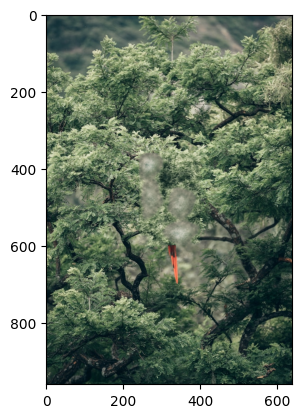

In [62]:
combo_1_network = DeepDIPNetwork().to(device)
combo_1_optimizer = torch.optim.Adam(combo_1_network.parameters(), lr=0.01)
combo_1_loss_fn = Perceptual_SSM_L1_Loss(
    perceptual_strength=0.10, 
    perceptual_layers=(3, 8, 15, 22),
    ssm_strength=0.7,
    L1_strength=0.2
).to(device)
DIP_image(
    input_image_path="./input_images/image_1.jpg", 
    iterations=100, 
    model_scale=8, 
    net=combo_1_network, 
    optimizer=combo_1_optimizer, 
    loss_fn=combo_1_loss_fn, 
    show_final=True, 
    save_final_file="./output_images/perc-ssm-l1/inpainted_1.jpg",
    print_loss_every=10
)
del combo_1_network
del combo_1_optimizer
del combo_1_loss_fn

Here I tried to combine all three of the methods we have seen, SSIM, L1, and perceptual loss function into a single loss function. After trial and error, I selected the hyperparameters: `perceptual_strength=0.1`, `ssm_strength=0.7`, `L1_strength=0.2`. This design aimed to blend the sharpness of SSIM, the tonal stability of L1, and the structural guidance of VGG-based perceptual loss into a unified loss landscape.

However I'm not impressed by this image. Two localized regions (top-right and bottom-left of the inpainted mask) exhibit convincing leaf-like textures and realistic shading, validating the potential of this mixed loss. However the overall inpainting is inconsistent with large portions remaining blurry and flat with a gray-green wash and that lacks contrast and variation. The boundaries are generally okay. 

I think this shows how calibration is needed. It takes a long time to try this model so I wasn't able to test extensively. Additionally, the limited number of iterations didn't help the perceptual aspect which tends to improve the image the more iterations. That is one thing to consider, how each method works over time. This shows how hard it can be to create hybrid loss functions.

# Deep Net using perceptual + SSIM + L1 + color + total variation loss function

Here I introduce two new loss methods, color loss and total variation. Throughout this project I spoke about color accuracy in the generation, now I will attempt such a loss function.

Additionally I will introduce a total variation loss function in order to try to get a smoother image. Previously there were many places in the image that changed quickly from one color to another, and TVL is typically used for smoothing so I thought to use that.

In [ ]:
def mean_color_loss(output, target, mask):
    known = mask.repeat(1, 3, 1, 1)
    hole = 1 - known
    masked_output_mean = (output * hole).sum(dim=(2, 3)) / (hole.sum(dim=(2, 3)) + 1e-6)
    known_target_mean = (target * known).sum(dim=(2, 3)) / (known.sum(dim=(2, 3)) + 1e-6)
    return F.mse_loss(masked_output_mean, known_target_mean)

class TotalVariationLoss(nn.Module):
    def forward(self, x):
        return torch.mean(torch.abs(x[:, :, :, :-1] - x[:, :, :, 1:])) + \
               torch.mean(torch.abs(x[:, :, :-1, :] - x[:, :, 1:, :]))

class Perceptual_SSM_L1_Color_TV_Loss(nn.Module):
    def __init__(self, 
                 perceptual_strength: float, 
                 perceptual_layers: Tuple[int, ...], 
                 ssm_strength: float, L1_strength: float,
                 color_strength: float, tv_strength: float
                ):
        super().__init__()
        self.perceptual_strength = perceptual_strength
        self.ssm_strength = ssm_strength
        self.L1_strength = L1_strength
        self.color_strength = color_strength
        self.tv_strength = tv_strength
        self.vgg_extractor = VGGFeatureExtractor(layers=perceptual_layers).to(device)
        self.tv = TotalVariationLoss().to(device)

    def forward(self, output, target, mask):
        mask3 = mask.repeat(1, 3, 1, 1)
        out_m = output * mask3
        tgt_m = target * mask3

        ssim_loss = 1 - ssim(out_m, tgt_m, data_range=1.0, size_average=True)
        l1_loss = F.l1_loss(out_m, tgt_m)
        perceptual_loss = sum(F.l1_loss(a, b) for a, b in zip(
            self.vgg_extractor(out_m), self.vgg_extractor(tgt_m)
        ))
        tv_loss = self.tv(output)
        color_loss = mean_color_loss(output, target, mask)

        return (self.ssm_strength * ssim_loss +
                self.L1_strength * l1_loss +
                self.perceptual_strength * perceptual_loss +
                self.color_strength * color_loss +
                self.tv_strength * tv_loss)

Iter 0, loss = 0.651622
Iter 10, loss = 0.485748
Iter 20, loss = 0.360445
Iter 30, loss = 0.268141
Iter 40, loss = 0.216705
Iter 50, loss = 0.185964
Iter 60, loss = 0.164373
Iter 70, loss = 0.148215
Iter 80, loss = 0.135323
Iter 90, loss = 0.124491
Iter 100, loss = 0.114188
Iter 110, loss = 0.101523
Iter 120, loss = 0.101813
Iter 130, loss = 0.091191
Iter 140, loss = 0.083284
Iter 150, loss = 0.085681
Iter 160, loss = 0.078536
Iter 170, loss = 0.074449
Iter 180, loss = 0.069401
Iter 190, loss = 0.066469
Iter 199, loss = 0.066247


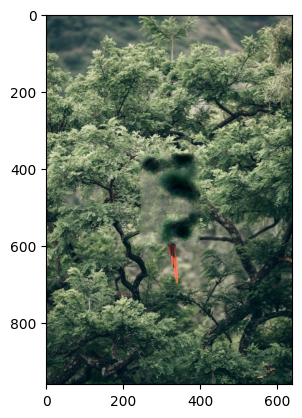

In [65]:
combo_2_network = DeepDIPNetwork().to(device)
combo_2_optimizer = torch.optim.Adam(combo_2_network.parameters(), lr=0.01)
combo_2_loss_fn = Perceptual_SSM_L1_Color_TV_Loss(
    perceptual_strength=0.05, 
    perceptual_layers=(3, 8, 15, 22),
    ssm_strength=0.6,
    L1_strength=0.2,
    tv_strength=0.05,
    color_strength=0.10
).to(device)
DIP_image(
    input_image_path="./input_images/image_1.jpg", 
    iterations=200, 
    model_scale=8, 
    net=combo_2_network, 
    optimizer=combo_2_optimizer, 
    loss_fn=combo_2_loss_fn, 
    show_final=True, 
    save_final_file="./output_images/perc-ssm-l1-color-tv/inpainted_1.jpg",
    print_loss_every=10
)
del combo_2_network
del combo_2_optimizer
del combo_2_loss_fn

Despite the idea of fixing the imperfection from previous model using more loss function, the results are underwhelming. It is structure-less and even has the wrong colors. My selection of hyperparameters might have been inperfect. It seems as if there is too much denoising by TVL. I think one thing that I forgot to consider was the effect over multiple iterations, even of weak components of the loss function. I think that even through TVL has a weak weighting, its effects compound over time. Similar to how the perceptual loss function gets right of noise quickly. TVL reduces noise which other loss functions won't add back but would have needed in order to generate structure. Thus the inpainted region remains with little structure. There is also a problem with the color loss since it has dark greens darker than any other green in the rest of the image. The trade-off involved in hybrid loss design are very delicate.

# Shallow Net using SSM + L1

Now I want to back back to basic and combine a simple shallow network with our improved SSIM+L1 loss function.

Iter 0, loss = 0.281826
Iter 10, loss = 0.142633
Iter 20, loss = 0.108564
Iter 30, loss = 0.096183
Iter 40, loss = 0.088104
Iter 50, loss = 0.082472
Iter 60, loss = 0.077339
Iter 70, loss = 0.072783
Iter 80, loss = 0.069347
Iter 90, loss = 0.065229
Iter 100, loss = 0.063377
Iter 110, loss = 0.059462
Iter 120, loss = 0.060010
Iter 130, loss = 0.056376
Iter 140, loss = 0.054200
Iter 150, loss = 0.052741
Iter 160, loss = 0.051653
Iter 170, loss = 0.050032
Iter 180, loss = 0.048975
Iter 190, loss = 0.049865
Iter 200, loss = 0.045163
Iter 210, loss = 0.044009
Iter 220, loss = 0.042618
Iter 230, loss = 0.042014
Iter 240, loss = 0.040380
Iter 250, loss = 0.039008
Iter 260, loss = 0.040520
Iter 270, loss = 0.036996
Iter 280, loss = 0.035930
Iter 290, loss = 0.035595
Iter 300, loss = 0.034460
Iter 310, loss = 0.034368
Iter 320, loss = 0.033588
Iter 330, loss = 0.033539
Iter 340, loss = 0.034905
Iter 350, loss = 0.031402
Iter 360, loss = 0.031671
Iter 370, loss = 0.031837
Iter 380, loss = 0.0299

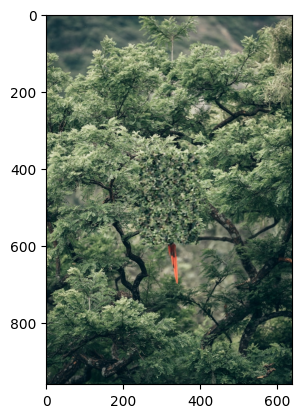

In [66]:
shallow_ssm_net = ShallowDIPNetwork().to(device)
shallow_ssm_optimizer = torch.optim.Adam(shallow_ssm_net.parameters(), lr=0.01)
shallow_ssm_loss_fn = SSIM_L1_Loss(alpha=0.1).to(device)
DIP_image(
    input_image_path="./input_images/image_1.jpg", 
    iterations=500, 
    model_scale=8, 
    net=shallow_ssm_net, 
    optimizer=shallow_ssm_optimizer, 
    loss_fn=shallow_ssm_loss_fn, 
    show_final=True, 
    save_final_file="./output_images/shallow-ssm-l1/inpainted_1.jpg",
    print_loss_every=10
)
del shallow_ssm_net
del shallow_ssm_optimizer
del shallow_ssm_loss_fn

This image is quite good. It still has the noisiness we saw in other shallow models, however the SSM-L1 loss (with strong preference for L1) has given it quite good sharpness. It also has correct color. However it has poor boundary blending, it is easy to see that the inpainted region is not natural. 

One thing that may be helping is the fact that the model is much faster, meaning that more iterations can be done in 10 minutes. This shows the advantage of simple loss functions (compared to the previous hybrid approaches) paired with a shallow and quick model. 

Next I will use the `DeeperDIPNetwork` to see if a very deep model can also benefit from SSIM-L1 loss function.

Iter 0, loss = 0.271439
Iter 10, loss = 0.155835
Iter 20, loss = 0.124155
Iter 30, loss = 0.102234
Iter 40, loss = 0.091961
Iter 50, loss = 0.083929
Iter 60, loss = 0.076022
Iter 70, loss = 0.071838
Iter 80, loss = 0.064124
Iter 90, loss = 0.058519
Iter 100, loss = 0.054371
Iter 110, loss = 0.053773
Iter 120, loss = 0.049973
Iter 130, loss = 0.047061
Iter 140, loss = 0.047303
Iter 150, loss = 0.042221
Iter 160, loss = 0.042014
Iter 170, loss = 0.037706
Iter 180, loss = 0.036235
Iter 190, loss = 0.035103
Iter 200, loss = 0.033761
Iter 210, loss = 0.032797
Iter 220, loss = 0.032175
Iter 230, loss = 0.031342
Iter 240, loss = 0.029988
Iter 249, loss = 0.032419


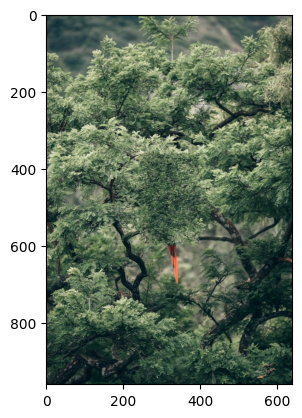

In [67]:
deeper_ssm_net = DeeperDIPNetwork().to(device)
deeper_ssm_optimizer = torch.optim.Adam(deeper_ssm_net.parameters(), lr=0.01)
deeper_ssm_loss_fn = SSIM_L1_Loss(alpha=0.1).to(device)
DIP_image(
    input_image_path="./input_images/image_1.jpg", 
    iterations=250, 
    model_scale=16, 
    net=deeper_ssm_net, 
    optimizer=deeper_ssm_optimizer, 
    loss_fn=deeper_ssm_loss_fn, 
    show_final=True, 
    save_final_file="./output_images/deeper-ssm-l1/inpainted_1.jpg",
    print_loss_every=10
)
del deeper_ssm_net
del deeper_ssm_optimizer
del deeper_ssm_loss_fn

This image is also quite good. It is similar to the shallow model's output however it is much darker. However it also produced leaf-like structure unlike the shallow model. It also seems noisier. The bottom border is pretty good, however the increased noisiness of the image make it clear that it is not natural. 

# Conclusion

Throughout this paper we saw the effect of the choice of a loss function on Deep Image Prior inpainting. As expected, MSE loss creates a blurry result, and this results is consistent across model depth. However using L1 greatly increases the sharpness of the result but not necessarily its structure or color. There is a similar result for SSIM. SSIM did well on the structure, not being too noisy compared to the rest of the image, however it struggled on color accuracy. Perceptual loss is computationally intensive but can create good results, it helps create a more semantically meaningful image which is more visually coherent. Additionally a perceptual loss approach can begin to imitate a GAN by using a classifier network (VGG16) as its loss function to guide generation. Although it does take a long time to converge to anything resembling what a simpler method would achieve. From this I combine multiple methods, including a color loss and total variation loss to mixed result. It seems like the hyperparameters controlling the mixing of hybrid loss functions are delicate to change. Additionally the number of iterations can play to some loss function's strengths/weaknesses and thereby have them be "over-represented" despite their seemingly weak weighting. We then examined simpler models using SSIM-L1 loss and they were quite impressive.

Overall I would say that hybrid approaches to deep image prior are difficult to get right, requiring a mix of loss function selection, hyperparameter tuning, and correctly choosing the number of iterations. And that the design of a loss function can be significantly more important than the model's depth.

For inpainting under time or compute constraints, a shallow model with SSIM+L1 offered a compelling tradeoff between realism and efficiency.

# Image Acknowledgements

1. `input_images/image_1.jpg` was taken by [Roberto Nickson](https://unsplash.com/photos/short-beak-red-bird-on-tree-6pE5ib-I5-o)
2. `input_images/image_2.jpg` was taken by [Hang Niu](https://unsplash.com/photos/white-kitten-Tn8DLxwuDMA)
3. `input_images/image_3.jpg` was taken by [Cédric VT](https://unsplash.com/photos/silver-tabby-cat-IuJc2qh2TcA)